<a href="https://colab.research.google.com/github/het7-5/student-success-agent/blob/main/Cluster_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas scikit-learn matplotlib seaborn openpyxl

Loaded 34,802 rows  ·  56 columns
All required columns found ✓
Date & Service filter applied: 34,802 → 24,623 appointments
Aggressive filter applied: 24,623 → 24,551 strictly 1-on-1 advising appointments

Appointment status breakdown:
appt_status
Attended                    18691
Cancelled                    3435
No-Show                      1626
Late Cancellation             798
Data Error / Flagged All        1
Student-level dataset: 15,429 unique students
       total_appts  lead_time_days_mean  self_booked_mean  is_noshow_mean  \
count     15429.00             15429.00          15429.00        15429.00   
mean          1.59                 6.83              0.88            0.05   
std           0.96                 5.90              0.30            0.17   
min           1.00                 0.00              0.00            0.00   
25%           1.00                 3.00              1.00            0.00   
50%           1.00                 6.00              1.00            0.00  

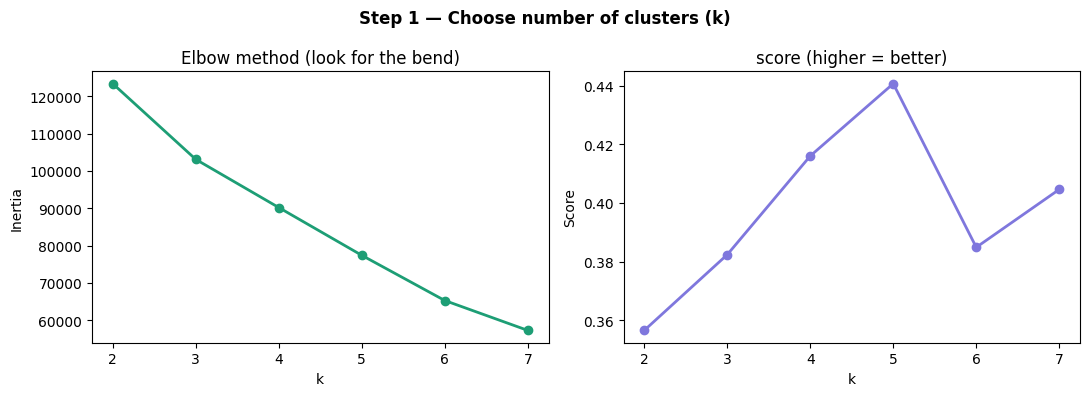

Saved → elbow_plot.png  ← look at this before setting CHOSEN_K below

Cluster sizes (k=5):
cluster
0    2646
1    1563
2    9325
3     643
4    1252

Final Cluster Labels:
cluster_label
Reliable Planners                    9325
Standard Cancellers                  2646
Staff-Initiated (Walk-ins/Triage)    1563
No-Shows (Ghosts)                    1252
Late Cancellers                       643


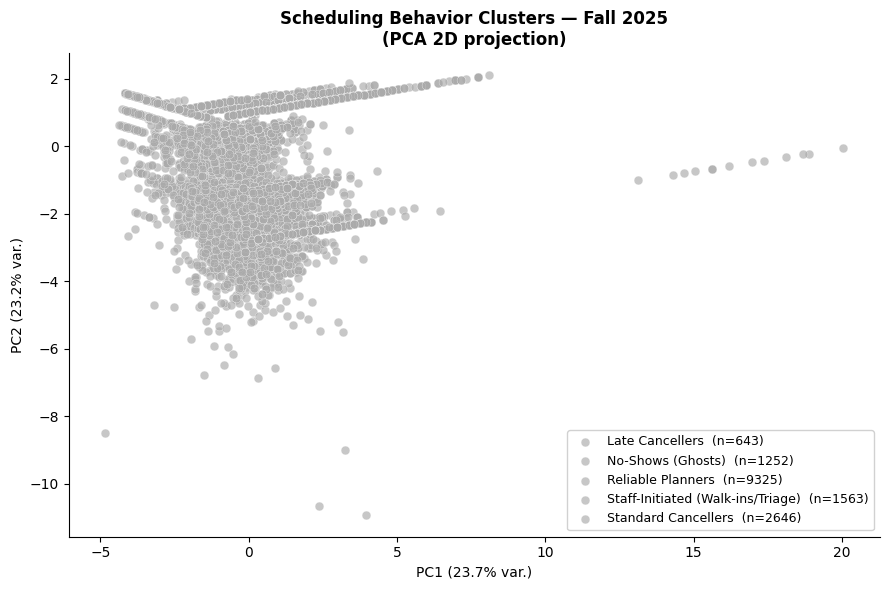

Saved → cluster_scatter.png


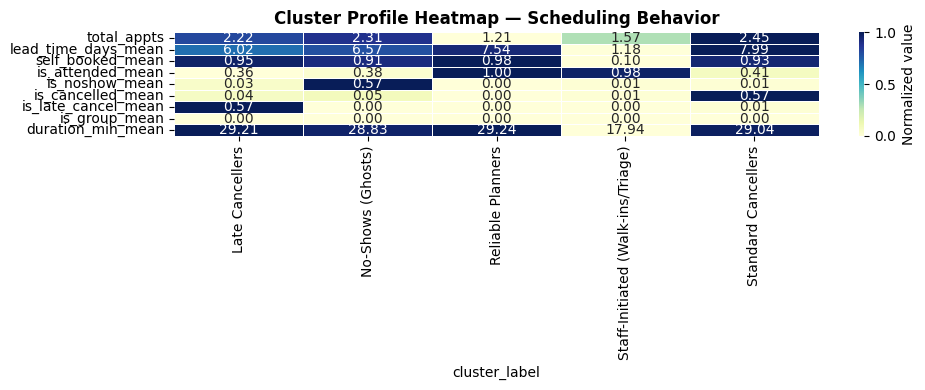

Saved → cluster_heatmap.png

Exported → students_with_clusters.csv

── Cluster Profile Summary ──
                                   total_appts  lead_time_days_mean  self_booked_mean  is_attended_mean  is_noshow_mean  is_cancelled_mean  is_late_cancel_mean  is_group_mean  duration_min_mean
cluster_label                                                                                                                                                                                    
Late Cancellers                           2.22                 6.02              0.95              0.36            0.03               0.04                 0.57            0.0              29.21
No-Shows (Ghosts)                         2.31                 6.57              0.91              0.38            0.57               0.05                 0.00            0.0              28.83
Reliable Planners                         1.21                 7.54              0.98              1.00            0.00       

In [1]:
"""
Scheduling Behavior Cluster Analysis — Fall 2025
=================================================
Clusters students by HOW and WHEN they book appointments.

Cluster types expected:
  • Planners         — book far in advance, self-booked
  • Last-minute      — book same/next day, self-booked
  • Staff-initiated  — advisor/staff created the appointment
  • Mixed / reactive — inconsistent patterns

Requirements:
    pip install pandas scikit-learn matplotlib seaborn openpyxl
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")


# ── 1. LOAD YOUR DATA ────────────────────────────────────────────────────────
# Your file is TAB-separated (.txt or .tsv export from EAB Navigate).
# Change FILE_PATH to your actual file location.

FILE_PATH = "/content/march 3.csv"   # ← change this (.txt / .tsv / .csv)

def load_data(path):
    ext = path.lower().split(".")[-1]
    if ext in ("xlsx", "xls"):
        df = pd.read_excel(path)
    elif ext in ("txt", "tsv"):
        df = pd.read_csv(
            path,
            sep="\t",
            encoding="utf-8",
            on_bad_lines="skip",
            engine="python",
            low_memory=False,
        )
    else:
        # Try tab first, fall back to comma
        try:
            df = pd.read_csv(path, sep="\t", encoding="utf-8",
                             on_bad_lines="skip", engine="python")
            if df.shape[1] < 5:
                raise ValueError
        except Exception:
            df = pd.read_csv(path, encoding="utf-8",
                             on_bad_lines="skip", engine="python")

    df.columns = df.columns.str.strip()
    print(f"Loaded {len(df):,} rows  ·  {df.shape[1]} columns")
    return df

df = load_data(FILE_PATH)


# ── 2. VERIFY REQUIRED COLUMNS ───────────────────────────────────────────────
REQUIRED = [
    "Student Name", "Student ID",
    "Scheduled Start Date", "Appointment Created At Date",
    "Scheduled Start Time", "Appointment Created By",
    "Scheduled Meeting Type", "Appointment Type",
    "Group Appointment?", "Late Cancel No Show?",
    "Appointment Summary No Show?", "Cancelled?",
    "Scheduled Duration (In Min)",
]
missing = [c for c in REQUIRED if c not in df.columns]
if missing:
    print(f"\n⚠️  Missing columns — check your file header:\n  {missing}")
else:
    print("All required columns found ✓")


# ── 3. PARSE DATES & TIMES ───────────────────────────────────────────────────
def parse_date(series):
    return pd.to_datetime(series.astype(str).str.strip(), errors="coerce")

def parse_time(series):
    # Handles "03:00 PM ET", "15:00", "3:00 PM"
    cleaned = series.astype(str).str.replace(r"\s+[A-Z]{2,3}$", "", regex=True).str.strip()
    for fmt in ("%I:%M %p", "%H:%M", "%I:%M:%S %p"):
        parsed = pd.to_datetime(cleaned, format=fmt, errors="coerce")
        if parsed.notna().sum() > len(series) * 0.5:
            return parsed.dt.time
    return pd.to_datetime(cleaned, infer_datetime_format=True, errors="coerce").dt.time

df["Scheduled Start Date"]        = parse_date(df["Scheduled Start Date"])
df["Appointment Created At Date"] = parse_date(df["Appointment Created At Date"])
df["_sched_time"]                  = parse_time(df["Scheduled Start Time"])


# ── 4. FILTER TO FALL 2025 ────────────────────────────────────────────────────
fall_start = pd.Timestamp("2025-08-01")
fall_end   = pd.Timestamp("2025-12-31")

before = len(df)

# Create a boolean mask for the dates
date_mask = (df["Scheduled Start Date"] >= fall_start) & (df["Scheduled Start Date"] <= fall_end)

# Create a boolean mask for the service type (using contains to be safe with messy data)
if "Scheduled Services" in df.columns:
    service_mask = df["Scheduled Services"].astype(str).str.contains("Academic Advising", case=False, na=False)
else:
    print("⚠️ 'Scheduled Services' column not found. Skipping service filter.")
    service_mask = True # Defaults to keeping everything if the column is missing

# Apply both filters
df = df[date_mask & service_mask].copy()

print(f"Date & Service filter applied: {before:,} → {len(df):,} appointments")

before = len(df)

# 1. Date mask
date_mask = (df["Scheduled Start Date"] >= fall_start) & (df["Scheduled Start Date"] <= fall_end)

# 2. Strict Service mask (Exact match instead of 'contains')
if "Scheduled Services" in df.columns:
    # Strip spaces and make lowercase for a perfectly safe exact match
    clean_services = df["Scheduled Services"].astype(str).str.strip().str.lower()
    service_mask = (clean_services == "academic advising")
else:
    print("⚠️ 'Scheduled Services' column not found.")
    service_mask = True

# 3. Explicitly REMOVE Group Appointments
if "Group Appointment?" in df.columns:
    individual_mask = df["Group Appointment?"].astype(str).str.strip().str.upper() != "YES"
else:
    print("⚠️ 'Group Appointment?' column not found.")
    individual_mask = True

# Apply all three filters
df = df[date_mask & service_mask & individual_mask].copy()

print(f"Aggressive filter applied: {before:,} → {len(df):,} strictly 1-on-1 advising appointments")


# ── 5. FEATURE ENGINEERING (per appointment row) ──────────────────────────────

# 5a. Lead time — days booked in advance
df["lead_time_days"] = (
    df["Scheduled Start Date"] - df["Appointment Created At Date"]
).dt.days.clip(lower=0)

# 5b. Self-booked — compare "Appointment Created By" to "Student Name"
#     Both are in "Last, First" format in your data
df["self_booked"] = (
    df["Appointment Created By"].astype(str).str.strip().str.lower()
    == df["Student Name"].astype(str).str.strip().str.lower()
).astype(int)

# 5c. Time of day bucket
def time_bucket(t):
    if pd.isna(t) or t is None:
        return "Unknown"
    try:
        h = t.hour
        if h < 12:   return "Morning"
        elif h < 17: return "Afternoon"
        else:        return "Evening"
    except Exception:
        return "Unknown"

df["time_of_day"] = df["_sched_time"].apply(time_bucket)

# 5d. Appointment status — derived from the three flag columns
def yn(series):
    """Normalise a Yes/No column to uppercase string."""
    return series.astype(str).str.strip().str.upper()

noshow_sum = yn(df["Appointment Summary No Show?"])
noshow_late = yn(df["Late Cancel No Show?"])
cancelled   = yn(df["Cancelled?"])

def appt_status(row):
    s, l, c = row["_ns_sum"], row["_ns_late"], row["_cancel"]
    if   s == "NO"  and l == "NO"  and c == "NO":  return "Attended"
    elif s == "NO"  and l == "NO"  and c == "YES": return "Cancelled"
    elif s == "YES" and l == "NO"  and c == "NO":  return "No-Show"
    elif s == "NO"  and l == "YES" and c == "YES": return "Late Cancellation"
    elif s == "YES" and l == "YES" and c == "YES": return "Data Error / Flagged All"
    else:                                           return "Other/Unknown"

df["_ns_sum"]  = noshow_sum
df["_ns_late"] = noshow_late
df["_cancel"]  = cancelled
df["appt_status"] = df[["_ns_sum","_ns_late","_cancel"]].apply(appt_status, axis=1)

print("\nAppointment status breakdown:")
print(df["appt_status"].value_counts().to_string())

# Convenience binary flags derived from status (used in aggregation below)
df["is_group"]         = yn(df["Group Appointment?"]).eq("YES").astype(int)
df["is_attended"]      = df["appt_status"].eq("Attended").astype(int)
df["is_noshow"]        = df["appt_status"].eq("No-Show").astype(int)
df["is_cancelled"]     = df["appt_status"].eq("Cancelled").astype(int)
df["is_late_cancel"]   = df["appt_status"].eq("Late Cancellation").astype(int)
df["is_data_error"]    = df["appt_status"].eq("Data Error / Flagged All").astype(int)

# 5e. Duration
df["duration_min"] = pd.to_numeric(df["Scheduled Duration (In Min)"], errors="coerce")

# 5f. One-hot: meeting type
meeting_dummies = pd.get_dummies(
    df["Scheduled Meeting Type"].astype(str).str.strip().str.title(),
    prefix="mtg"
).astype(int)
df = pd.concat([df, meeting_dummies], axis=1)
meeting_cols = [c for c in df.columns if c.startswith("mtg_")]

# 5g. One-hot: appointment type (Scheduled / Walk-In / etc.)
# NOTE: prefix is "atype_" (not "appt_") to avoid collision with appt_status column
appttype_dummies = pd.get_dummies(
    df["Appointment Type"].astype(str).str.strip().str.title(),
    prefix="atype"
).astype(int)
df = pd.concat([df, appttype_dummies], axis=1)
appttype_cols = [c for c in df.columns if c.startswith("atype_")]

# 5h. One-hot: time of day
tod_dummies = pd.get_dummies(df["time_of_day"], prefix="tod").astype(int)
df = pd.concat([df, tod_dummies], axis=1)
tod_cols = [c for c in df.columns if c.startswith("tod_")]


# ── 6. AGGREGATE TO STUDENT LEVEL ────────────────────────────────────────────
agg_dict = {
    "Scheduled Start Date": "count",
    "lead_time_days":       ["mean", "min", "std"],
    "self_booked":          "mean",
    "is_group":             "mean",
    "is_attended":          "mean",   # attendance rate
    "is_noshow":            "mean",   # no-show rate
    "is_cancelled":         "mean",   # cancellation rate
    "is_late_cancel":       "mean",   # late cancellation rate
    "is_data_error":        "mean",   # data quality flag
    "duration_min":         "mean",
}
for col in meeting_cols + appttype_cols + tod_cols:
    agg_dict[col] = "mean"

student_df = df.groupby("Student ID").agg(agg_dict)
student_df.columns = ["_".join(filter(None, map(str, c))) for c in student_df.columns]
student_df = student_df.rename(columns={"Scheduled Start Date_count": "total_appts"})
student_df["lead_time_days_std"] = student_df.get(
    "lead_time_days_std", pd.Series(0, index=student_df.index)
).fillna(0)
student_df = student_df.reset_index()

# Attach student metadata for the export
meta_cols = ["Student ID", "Student Name"]
for c in ["Classification", "Cumulative GPA", "Majors", "College", "Assigned Staff"]:
    if c in df.columns:
        meta_cols.append(c)

name_map = df.drop_duplicates("Student ID")[meta_cols].copy()
student_df = student_df.merge(name_map, on="Student ID", how="left")

print(f"Student-level dataset: {len(student_df):,} unique students")
print(student_df[["total_appts", "lead_time_days_mean", "self_booked_mean",
                   "is_noshow_mean", "is_cancelled_mean"]].describe().round(2))


# ── 7. FEATURE MATRIX ─────────────────────────────────────────────────────────
core = [
    "total_appts",
    "lead_time_days_mean", "lead_time_days_min", "lead_time_days_std",
    "self_booked_mean",
    "is_group_mean",
    "is_attended_mean",
    "is_noshow_mean",
    "is_cancelled_mean",
    "is_late_cancel_mean",
    "duration_min_mean",
]
feature_cols = [c for c in core + meeting_cols + appttype_cols + tod_cols
                if c in student_df.columns]

X = student_df[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ── 8. ELBOW PLOT — CHOOSE K ──────────────────────────────────────────────────
inertias, silhouettes = [], []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Step 1 — Choose number of clusters (k)", fontsize=12, fontweight="bold")
axes[0].plot(list(K_range), inertias, "o-", color="#1D9E75", linewidth=2)
axes[0].set_title("Elbow method (look for the bend)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(K_range), silhouettes, "o-", color="#7F77DD", linewidth=2)
axes[1].set_title("score (higher = better)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → elbow_plot.png  ← look at this before setting CHOSEN_K below")


# ── 9. FIT FINAL MODEL ───────────────────────────────────────────────────────
# Review elbow_plot.png, then set CHOSEN_K to the bend point.
CHOSEN_K = 5

km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
student_df["cluster"] = km_final.fit_predict(X_scaled)
print(f"\nCluster sizes (k={CHOSEN_K}):")
print(student_df["cluster"].value_counts().sort_index().to_string())


# ── 10. AUTO-LABEL CLUSTERS (REVISED FOR 1-ON-1 ADVISING) ────────────────────
centers = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=feature_cols
)

def auto_label(row):
    self_b = row.get("self_booked_mean", 0.5)
    noshow = row.get("is_noshow_mean", 0)
    cancel = row.get("is_cancelled_mean", 0)
    late_cancel = row.get("is_late_cancel_mean", 0)

    if self_b < 0.35:
        return "Staff-Initiated (Walk-ins/Triage)"

    # Check for the specific types of problematic behavior
    if late_cancel > 0.30:
        return "Late Cancellers"
    if noshow > 0.30:
        return "No-Shows (Ghosts)"
    if cancel > 0.30:
        return "Standard Cancellers"

    return "Reliable Planners"

centers["label"] = centers.apply(auto_label, axis=1)
cluster_labels = centers["label"].to_dict()

# Apply the labels to the main dataframe
student_df["cluster_label"] = student_df["cluster"].map(cluster_labels)

print("\nFinal Cluster Labels:")
print(student_df["cluster_label"].value_counts().to_string())


# ── 11. PCA SCATTER ───────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
student_df["pca_x"] = coords[:, 0]
student_df["pca_y"] = coords[:, 1]

palette = {
    "Planner":          "#1D9E75",
    "Last-minute":      "#EF9F27",
    "Staff-initiated":  "#7F77DD",
    "Inconsistent":     "#D85A30",
    "Mixed / reactive": "#888780",
    "Mixed / reactive": "#887780",

}

fig, ax = plt.subplots(figsize=(9, 6))
for label, grp in student_df.groupby("cluster_label"):
    ax.scatter(grp["pca_x"], grp["pca_y"],
               label=f"{label}  (n={len(grp)})",
               color=palette.get(label, "#aaa"),
               alpha=0.65, s=40, edgecolors="white", linewidths=0.3)
ax.set_title("Scheduling Behavior Clusters — Fall 2025\n(PCA 2D projection)",
             fontsize=12, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.legend(framealpha=0.9, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("cluster_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → cluster_scatter.png")


# ── 12. HEATMAP ───────────────────────────────────────────────────────────────
profile_cols = [c for c in [
    "total_appts", "lead_time_days_mean", "self_booked_mean",
    "is_attended_mean", "is_noshow_mean",
    "is_cancelled_mean", "is_late_cancel_mean",
    "is_group_mean", "duration_min_mean"
] if c in student_df.columns]

profile = student_df.groupby("cluster_label")[profile_cols].mean().round(2)
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(profile_norm.T, annot=profile.T, fmt=".2f",
            cmap="YlGnBu", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Normalized value"})
ax.set_title("Cluster Profile Heatmap — Scheduling Behavior", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → cluster_heatmap.png")


# ── 13. EXPORT ────────────────────────────────────────────────────────────────
out_cols = [c for c in [
    "Student ID", "Student Name", "cluster", "cluster_label",
    "total_appts", "lead_time_days_mean", "self_booked_mean",
    "is_attended_mean", "is_noshow_mean", "is_cancelled_mean", "is_late_cancel_mean",
    "Classification", "Cumulative GPA", "Majors", "College", "Assigned Staff"
] if c in student_df.columns]

student_df[out_cols].to_csv("students_with_clusters.csv", index=False)
print("\nExported → students_with_clusters.csv")

print("\n── Cluster Profile Summary ──")
print(profile.to_string())
print("\nDone ✓")


── Building Predictive Cancellation Model ──

Classification Report (Test Data):
                   precision    recall  f1-score   support

         Attended       0.86      0.42      0.57      3900
Cancelled/No-Show       0.25      0.74      0.37      1011

         accuracy                           0.49      4911
        macro avg       0.55      0.58      0.47      4911
     weighted avg       0.74      0.49      0.53      4911



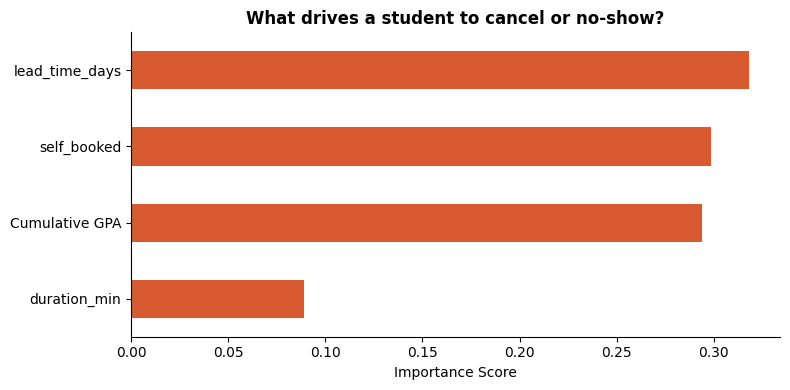

Saved → cancellation_drivers.png


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\n── Building Predictive Cancellation Model ──")

# 1. DEFINE THE TARGET VARIABLE
# 1 = "Bad" outcome (Cancelled or No-Show), 0 = "Good" outcome (Attended)
df["target_risk"] = (df["is_noshow"] | df["is_cancelled"]).astype(int)

# 2. SELECT THE FEATURES (The "Clues")
# Start with the behavioral engineered features you already built
feature_cols = [
    "lead_time_days",
    "self_booked",
    "duration_min"
]

# If you have student demographic data in the row-level df, add it!
# (e.g., GPA, First-Gen status, Credits Earned)
if "Cumulative GPA" in df.columns:
    df["Cumulative GPA"] = pd.to_numeric(df["Cumulative GPA"], errors="coerce").fillna(df["Cumulative GPA"].median())
    feature_cols.append("Cumulative GPA")

X = df[feature_cols].fillna(0)
y = df["target_risk"]

# 3. SPLIT THE DATA
# 80% to train the model, 20% to test it on data it has never seen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. FIT THE RANDOM FOREST
# We use class_weight="balanced" because most students actually show up,
# and we want the model to pay extra attention to the ones who don't.
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

# 5. EVALUATE PERFORMANCE
y_pred = rf_model.predict(X_test)
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_pred, target_names=["Attended", "Cancelled/No-Show"]))

# 6. FEATURE IMPORTANCE (The "Why")
importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind="barh", color="#D85A30", ax=ax)
ax.set_title("What drives a student to cancel or no-show?", fontweight="bold")
ax.set_xlabel("Importance Score")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("cancellation_drivers.png", dpi=150)
plt.show()
print("Saved → cancellation_drivers.png")

In [21]:
import pandas as pd

df = pd.read_csv("/content/students_with_clusters.csv")

print("\n--- 1. Cluster Breakdown by Student Classification ---")
# Creates a percentage matrix showing the makeup of each cluster
class_crosstab = pd.crosstab(
    df['cluster_label'],
    df['Classification'],
    normalize='index' # Shows row percentages
) * 100
print(class_crosstab.round(1).astype(str) + "%")


print("\n--- 2. Cluster Breakdown by GPA Tiers ---")
# Create GPA bins to make the data readable
df['GPA_Tier'] = pd.cut(
    df['Cumulative GPA'],
    bins=[0, 2.0, 2.5, 3.0, 3.5, 4.0],
    labels=['<2.0', '2.0-2.5', '2.5-3.0', '3.0-3.5', '3.5-4.0']
)
gpa_crosstab = pd.crosstab(df['cluster_label'], df['GPA_Tier'], normalize='index') * 100
print(gpa_crosstab.round(1).astype(str) + "%")


--- 1. Cluster Breakdown by Student Classification ---
Classification                    Freshman (Fall 2023) Freshman (Fall 2024)  \
cluster_label                                                                 
Late Cancellers                                   0.0%                 0.0%   
No-Shows (Ghosts)                                 0.1%                 0.0%   
Reliable Planners                                 0.0%                 0.0%   
Staff-Initiated (Walk-ins/Triage)                 0.0%                 0.0%   
Standard Cancellers                               0.0%                 0.0%   

Classification                    Freshman (Fall 2025) Freshman (Spring 2022)  \
cluster_label                                                                   
Late Cancellers                                   0.8%                   0.0%   
No-Shows (Ghosts)                                 1.7%                   0.1%   
Reliable Planners                                 1.1%            